In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
using SSMCMain.ModifiedMiCRM, SSMCMain.ModifiedMiCRM.MinimalModelV2, SSMCMain.ModifiedMiCRM.TwoMMs
includet("../../../scripts/single_influx.jl")

In [3]:
using ProgressMeter
using ColorSchemes
using UnPack

In [4]:
includet("../../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Setup

In [5]:
function spaced_subset(t::AbstractVector, Δt; tmin=first(t), tmax=last(t))
    idx = Int[]

    # Find first point within time window
    start_idx = findfirst(≥(tmin), t)
    if start_idx === nothing
        return idx
    end

    last_t = t[start_idx]
    push!(idx, start_idx)

    for i in (start_idx + 1):length(t)
        if t[i] > tmax
            break
        end

        if t[i] - last_t ≥ Δt
            push!(idx, i)
            last_t = t[i]
        end
    end

    return idx
end

spaced_subset (generic function with 1 method)

In [6]:
function plot_spacetime(sol, sN, dx, dt;
    fsmap=x->x[1,:],
    tmin=0.,
    tmax=Inf,
    kwargs...
)

    x_boundaries = (0:sN) .* dx
    extrema(x_boundaries), length(x_boundaries)

    tis = spaced_subset(sol.t, dt; tmin, tmax)
    ts = sol.t[tis]
    us = sol.u[tis];
    
    t_boundaries = Float64[]
    for i in 2:length(ts)
        t = ts[i]
        prev_t = ts[i-1]
        push!(t_boundaries, (prev_t + t) / 2)
    end
    push!(t_boundaries, ts[end])
    
    xx = hcat((map(us[2:end]) do x fsmap(x) end)...);
    
    heatmap(x_boundaries, t_boundaries, xx; kwargs...)
end

plot_spacetime (generic function with 1 method)

# Single MM

In [143]:
mmp = MMParams(;
    K=15.,
    m=1.,
    c=1.,
    l=1.,
)
T = 1e8
tol = 1e-8

ode_ps = mmp_to_mmicrm(mmp;
    static=false,
)
ode_p = make_mmicrm_problem(ode_ps, [1., 0., 0.], T)
ode_s = solve(ode_p, QNDF();
    abstol=tol,
    reltol=tol,
)
@show mmicrmmaxresid(ode_s) ode_s.u[end];

mmicrmmaxresid(ode_s) = 0.0
ode_s.u[end] = [12.922616289332565, 1.0773837106674355, 1.0]


In [144]:
DN = 1e-6
DR = 1.

L = 10
sN = 2000

# u0 = expand_u0_to_size((sN,), ode_s.u[end])
# u0 = perturb_u0_uniform(1, 2, u0, 1e-3)

meanN0, numwaves, waveampfactor = 1.0, 100, 100.0
u0 = get_siny_u0(1, 2, sN, dx, meanN0, numwaves, waveampfactor)

dx = L / sN

pde_ps = BSMMiCRMParams(ode_ps, [DN, 1., DR], CartesianSpace{1, Tuple{Periodic}}([dx]), nthreads())
pde_p = make_smmicrm_problem(pde_ps, u0, T);
@time pde_s = solve(pde_p, QNDF();
    callback=make_timer_callback(10),
    abstol=tol,
    reltol=tol,
);
@show smmicrmmaxresid(pde_s);

  5.886593 seconds (3.05 M allocations: 1.684 GiB, 25.62% gc time)
smmicrmmaxresid(pde_s) = 3.4029881135211326e-9


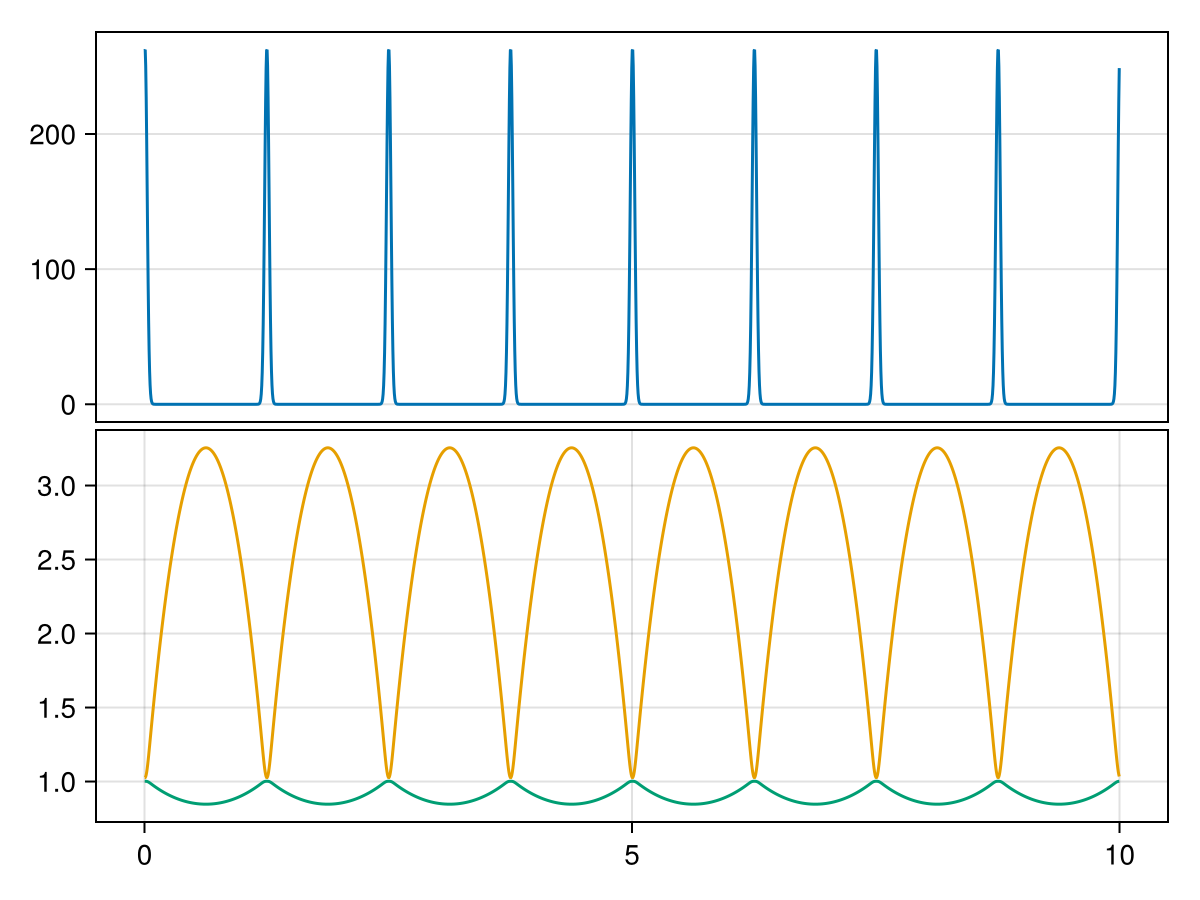

In [146]:
plot_spatial_fs(pde_s.u[end], 1, sN, dx)

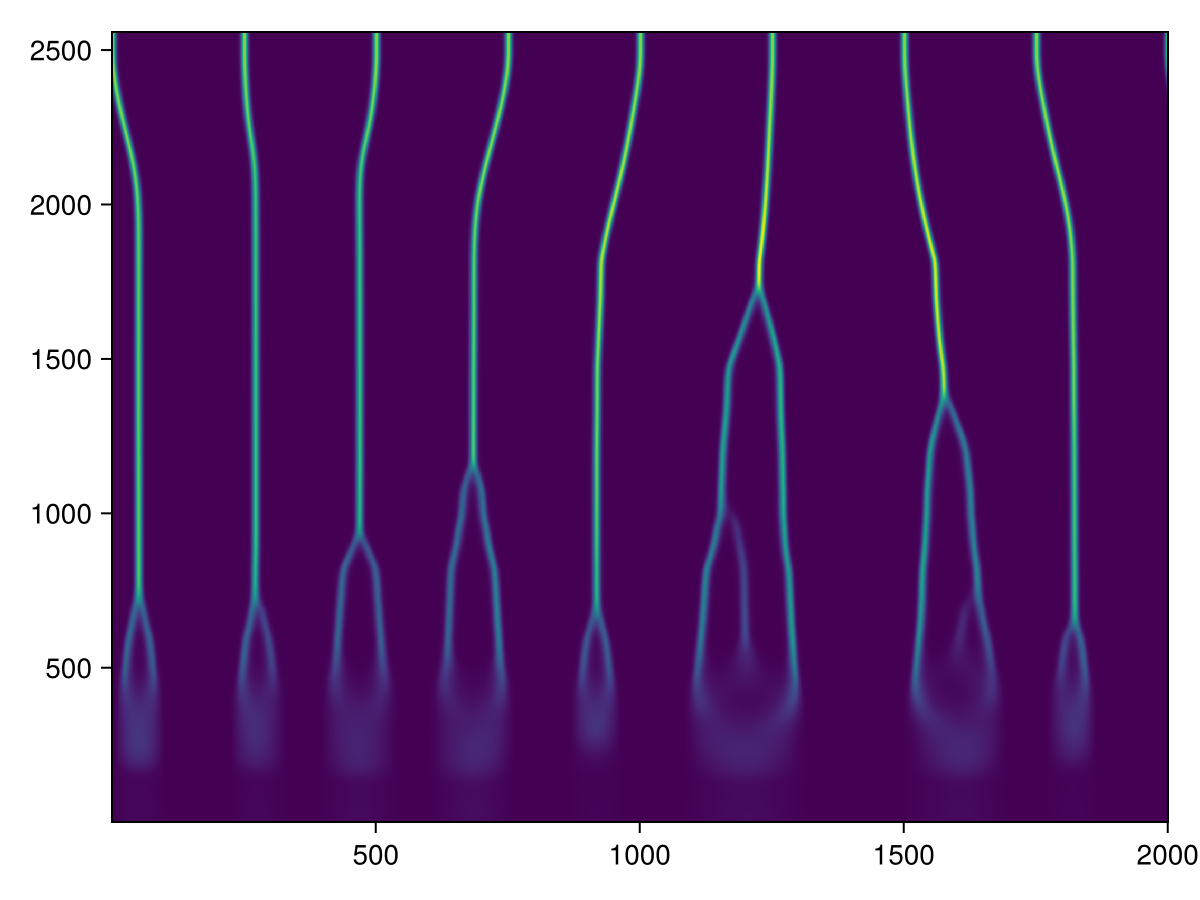

In [147]:
xx = hcat((map(pde_s.u) do x x[1,:] end)...);
fap = heatmap(xx)
# Makie.save("../../../figures2/fig3/mm_coarsening_demo.png", fap.figure)
fap

## Heatmap with correct time direct

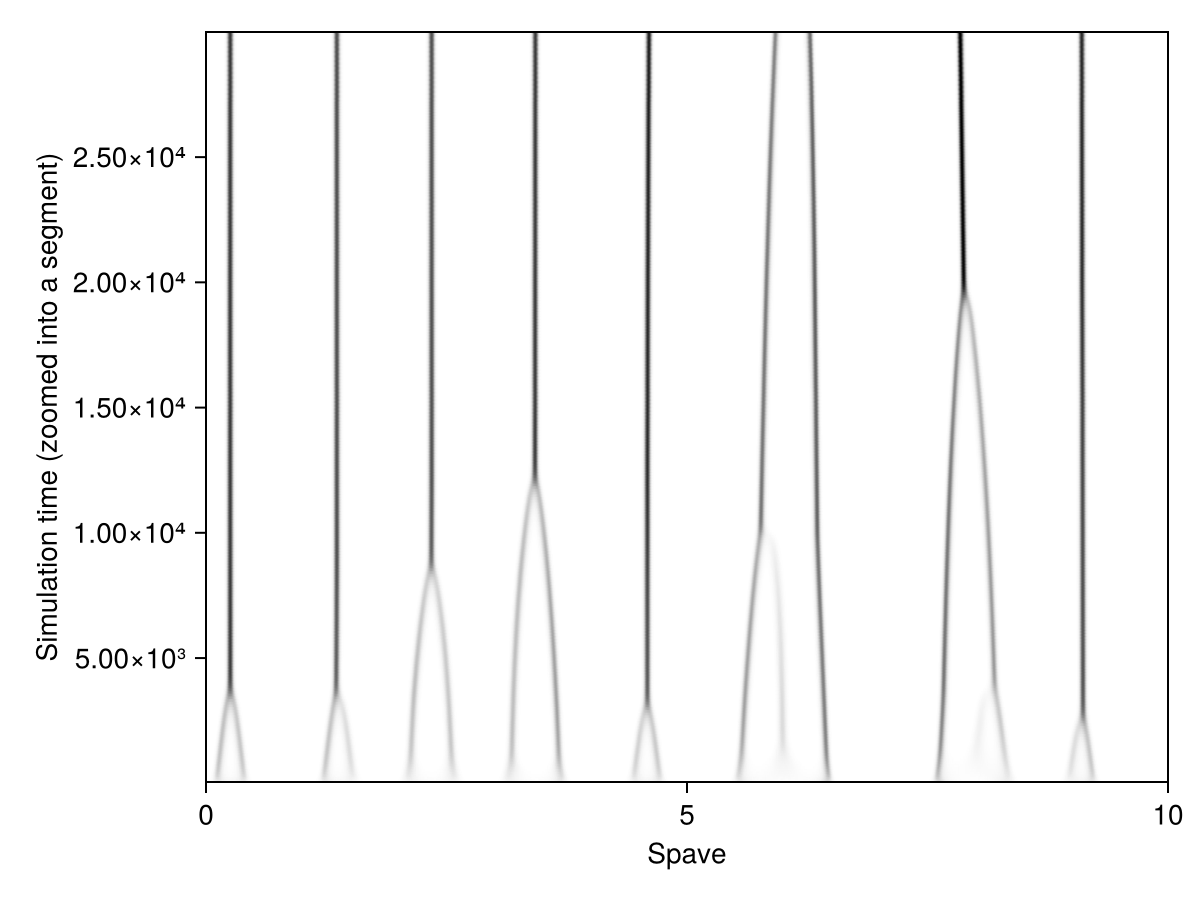

In [152]:
fap = plot_spacetime(pde_s, sN, dx, 1e2;
    tmin=0.,
    tmax=3e4,
    colormap=ColorSchemes.Greys,
)
fap.axis.xlabel = "Spave"
fap.axis.ylabel = "Simulation time (zoomed into a segment)"
Makie.save("./onemm_sample.pdf", fap.figure)
fap

# Two MMs

In [7]:
tmmp = TMMsParams(;
    K=15.,
    m1=0.9,
    c1=0.9,
    l1=1.,
    m2=1.0,
    c2=1.0,
    l2=1.,
)
T = 1e8
tol = 1e-8

ode_ps = tmmsp_to_mmicrm(tmmp;
)
ode_p = make_mmicrm_problem(ode_ps, [1., 1., 0., 0., 0.], T)
ode_s = solve(ode_p, QNDF();
    abstol=tol,
    reltol=tol,
)
@show mmicrmmaxresid(ode_s) ode_s.u[end];

mmicrmmaxresid(ode_s) = 5.829208930701052e-26
ode_s.u[end] = [-9.261949916823824e-31, 12.922616289332565, 1.0773837106674355, -5.829298738766776e-26, 1.0]


In [8]:
DN = 1e-6
DR = 1.

L = 10
sN = 2000
dx = L / sN

meanN0, numwaves, waveampfactor = 1.0, 100, 100.0

u0 = get_siny_u0(2, 3, sN, dx, meanN0, numwaves, waveampfactor)

pde_ps = BSMMiCRMParams(ode_ps, [DN, DN, 1., DR, DR], CartesianSpace{1, Tuple{Periodic}}([dx]), nthreads())
pde_p = make_smmicrm_problem(pde_ps, u0, T);
@time pde_s = solve(pde_p, QNDF();
    callback=make_timer_callback(20),
    abstol=tol,
    reltol=tol,
);
@show smmicrmmaxresid(pde_s);


 22.377256 seconds (14.58 M allocations: 4.968 GiB, 3.33% gc time, 36.91% compilation time)
smmicrmmaxresid(pde_s) = 6.517453243759519e-11


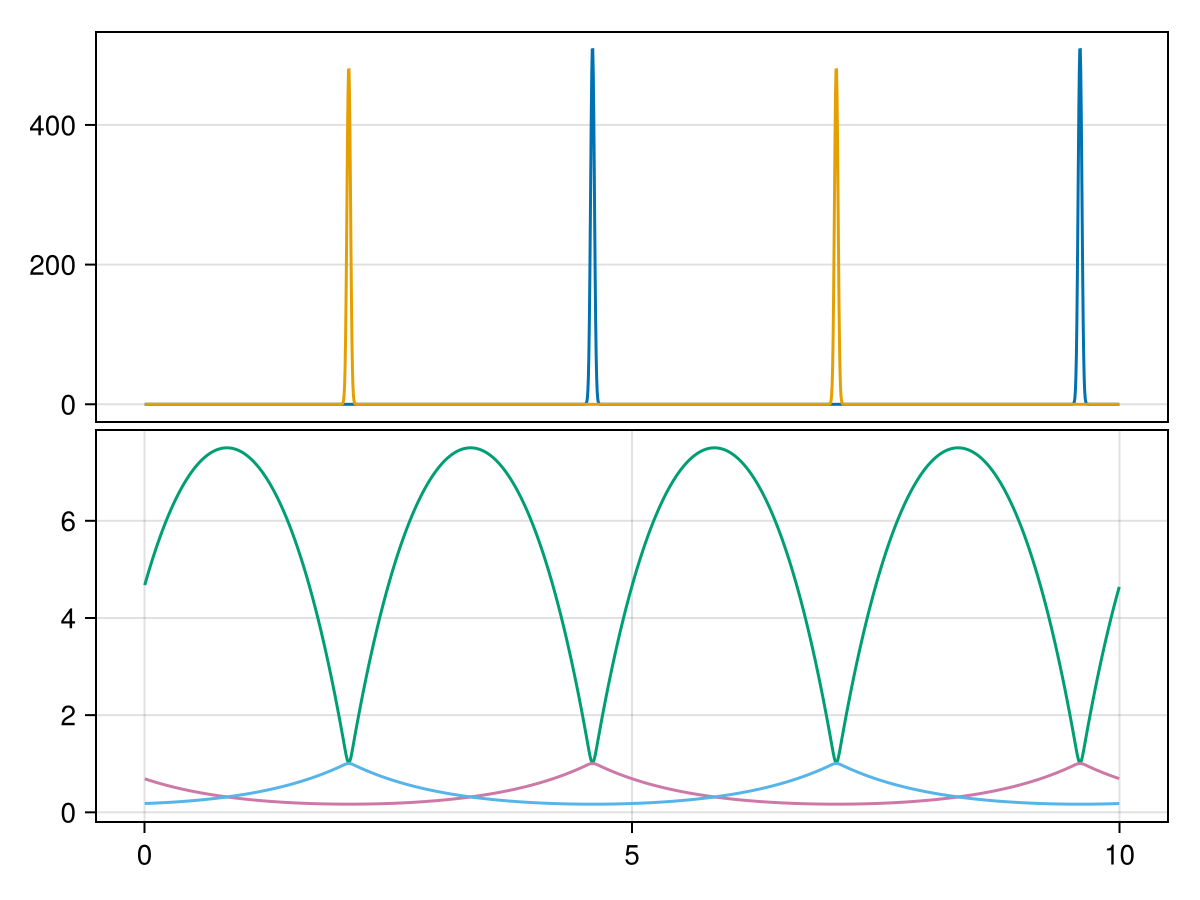

In [9]:
plot_spatial_fs(pde_s.u[end], 2, sN, dx)

## Heatmap with correct time direct

In [160]:
function tmms_fsmap(x)
    sN = size(x, 2)
    cs = Vector{Any}(undef, sN)
    for i in 1:sN
        n1 = x[1, i]
        n2 = x[2, i]
        tot = n1 + n2
        pol = if tot > eps()
            (((n1 - n2) / tot) + 1) / 2
        else
            0.5
        end
        cs[i] = get(ColorSchemes.RdBu, pol)
    end
    cs
end

tmms_fsmap (generic function with 1 method)

In [161]:
function tmms_fsmap2(x, totmax)
    sN = size(x, 2)
    cs = Vector{Any}(undef, sN)
    for i in 1:sN
        n1 = x[1, i]
        n2 = x[2, i]
        tot = n1 + n2
        pol = if tot > eps()
            (((n1 - n2) / tot) + 1) / 2
        else
            0.5
        end
        cs[i] = get(cgrad([colorant"white", get(ColorSchemes.RdBu, pol)]), tot / totmax)
    end
    cs
end

tmms_fsmap2 (generic function with 2 methods)

In [162]:
maxtot = maximum(pde_s.u) do fs maximum(fs[1:2,:]) end

494.49163580632967

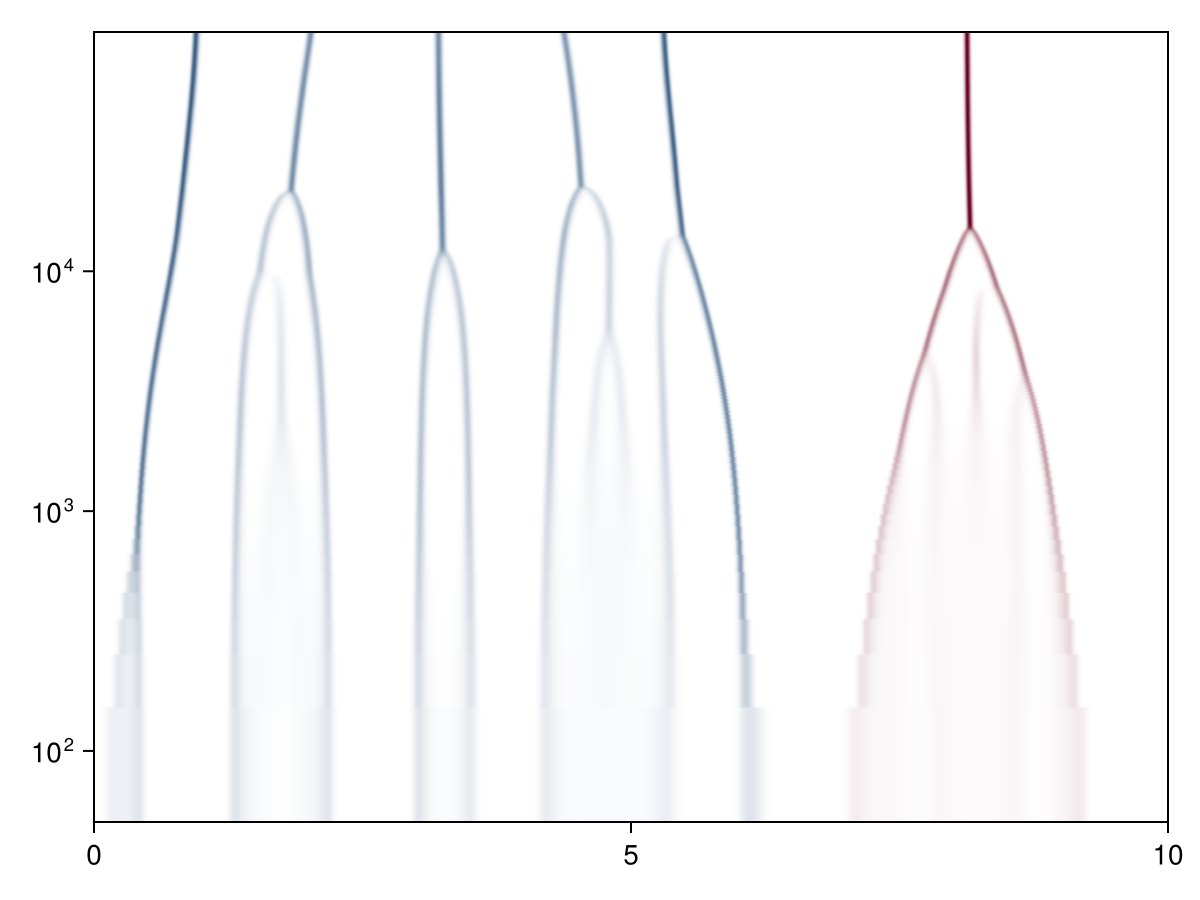

In [169]:
fap = plot_spacetime(pde_s, sN, dx, 1e2;
    fsmap=x->tmms_fsmap2(x, maxtot),
    tmin=0.,
    tmax=1e5,
)

fap.axis.yscale=log10

fap

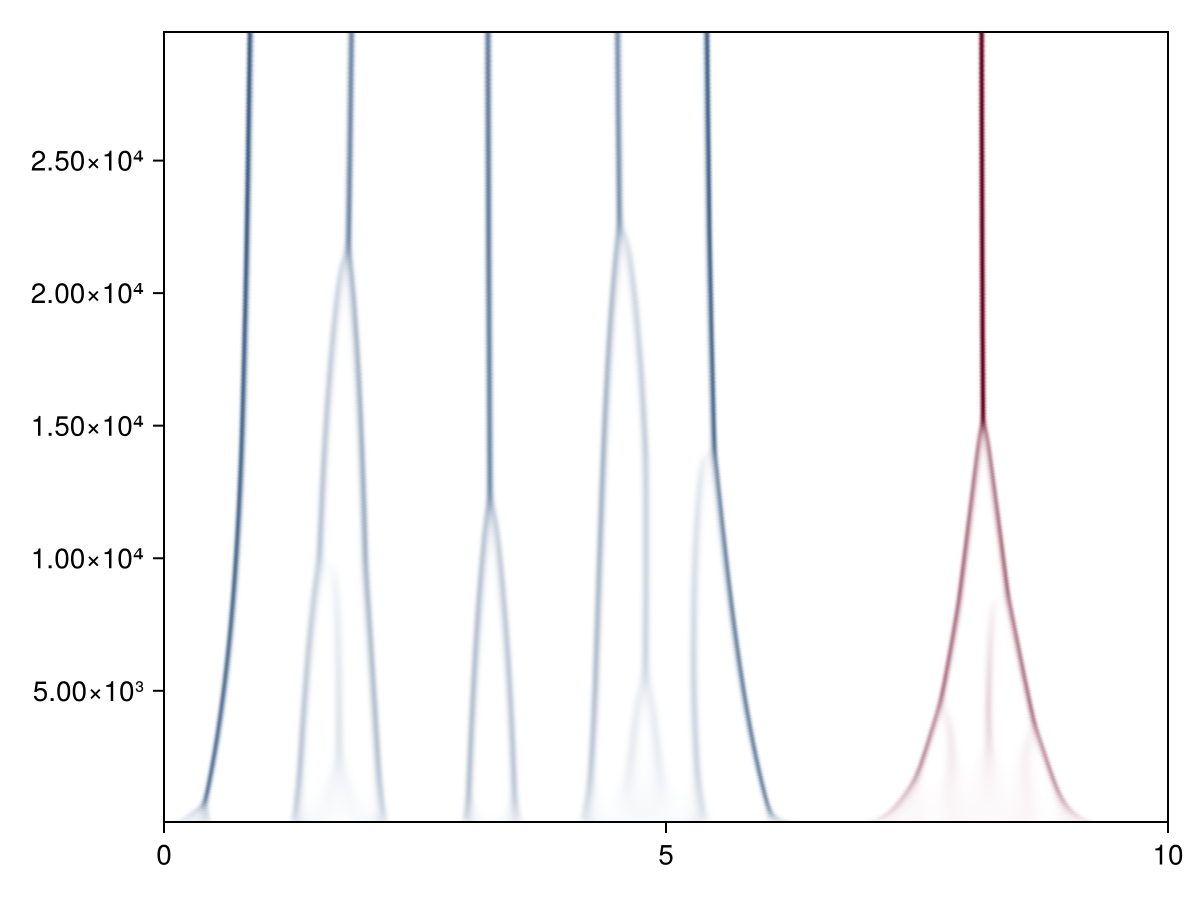

In [164]:
fap = plot_spacetime(pde_s, sN, dx, 1e2;
    fsmap=x->tmms_fsmap2(x, maxtot),
    tmin=0.,
    tmax=3e4,
)
# fap.axis.xlabel = "Spave"
# fap.axis.ylabel = "Simulation time (zoomed into a segment)"
# Makie.save("./twomms_sample.pdf", fap.figure)
fap

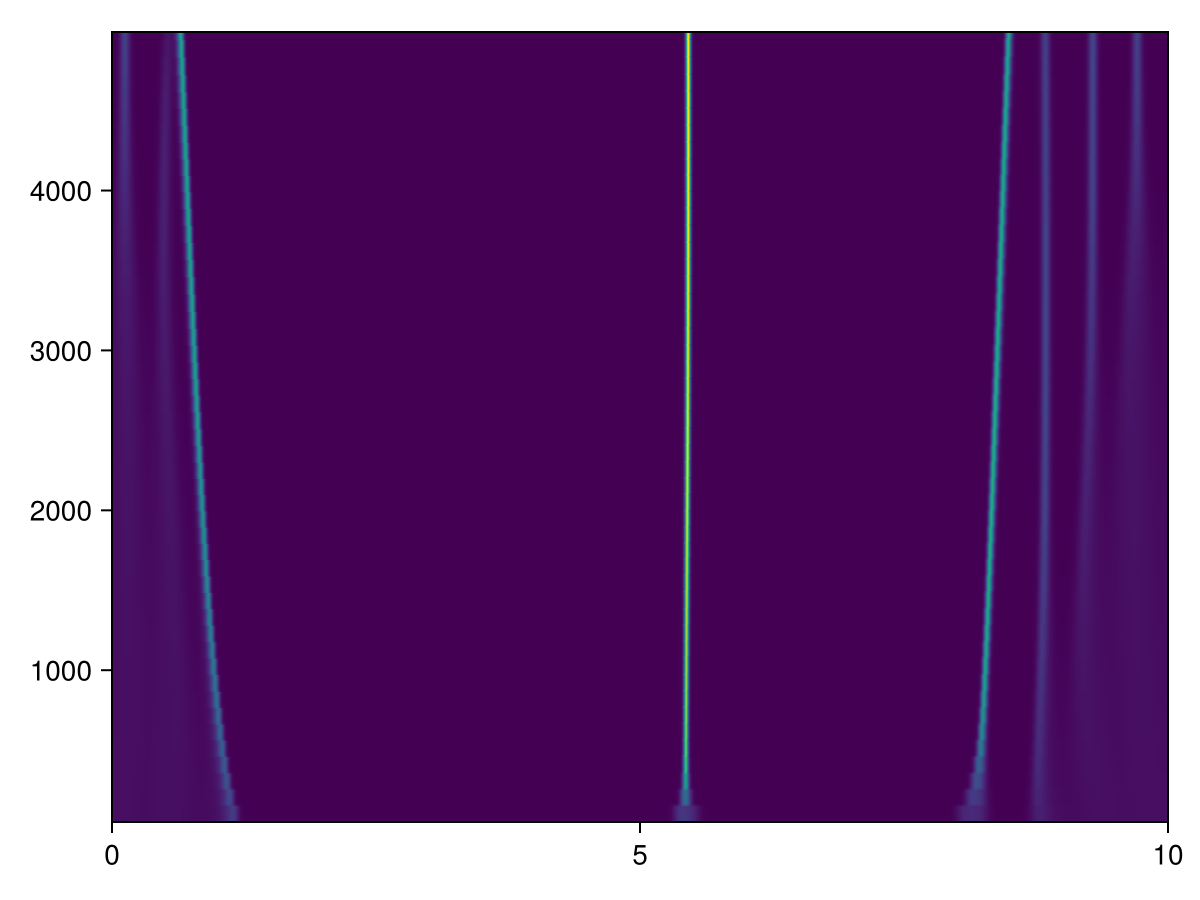

In [ ]:
plot_spacetime(pde_s, sN, dx, 1e2;
    fsmap=x->x[2,:],
    tmin=0.,
    tmax=5e3,
)

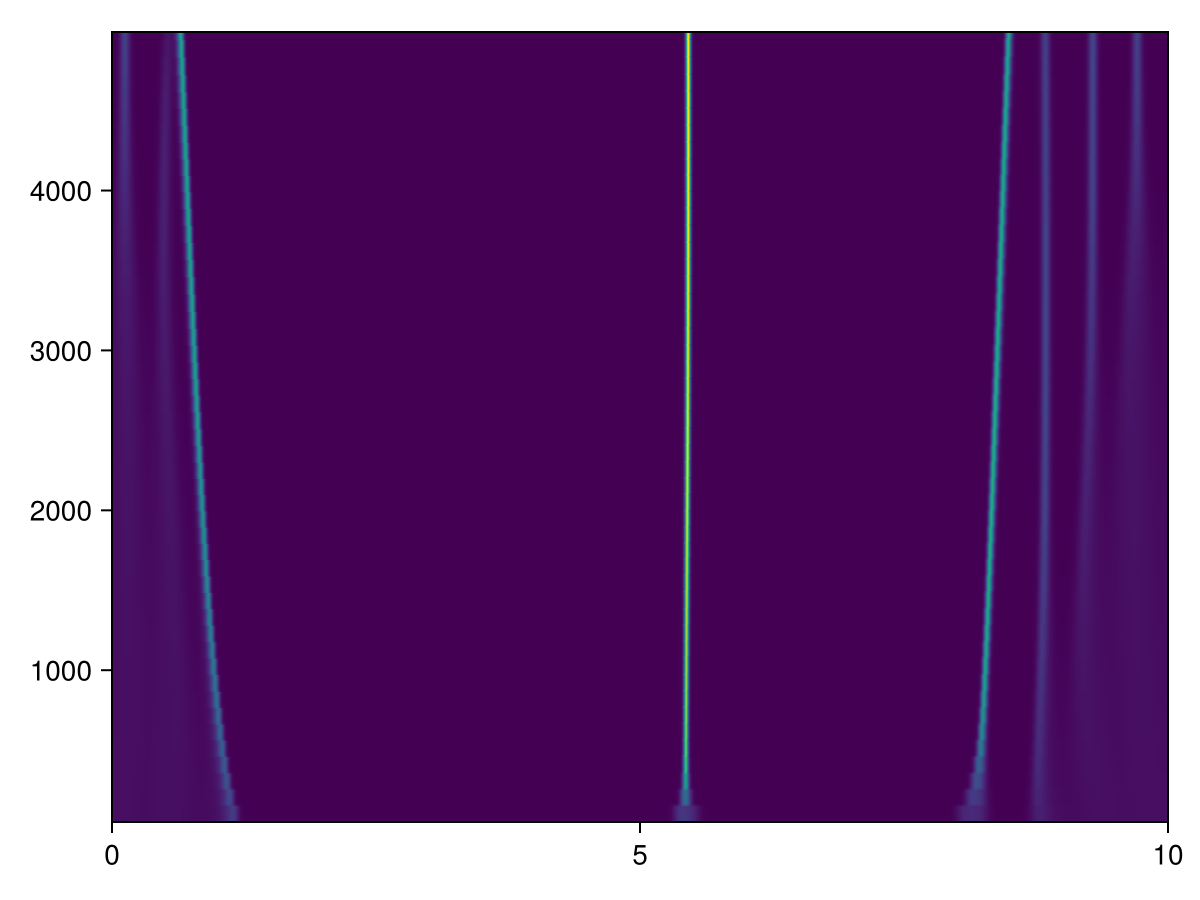

In [ ]:
plot_spacetime(pde_s, sN, dx, 1e2;
    fsmap=x->x[2,:],
    tmin=0.,
    tmax=5e3,
    colormap=ColorSchemes.Greys
)